In [1]:
import numpy as np 
import pandas as pd
import os
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import matplotlib as mpl
from descartes import PolygonPatch
import fiona
import re
import subprocess
from multiprocess import Pool
import fnmatch
from datetime import datetime, timedelta
import gdal
from osgeo.gdalconst import *
from osgeo.gdalnumeric import *
%matplotlib inline


[Text(0, 0.5, 'Count'), Text(0.5, 0, 'Area (km2)')]

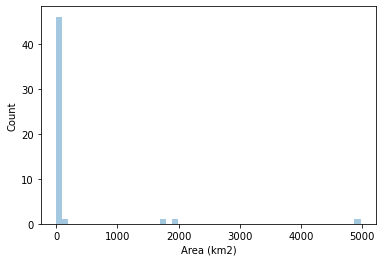

In [71]:
## Plot fire size and length distributions
os.chdir('/p8/fdlausnz/yshendryk/risk_heatmaping/data/vector/')
# Fire size:
fires = gpd.read_file('Fire_NPWSFireHistory_2018_2020_T56HKJ_clip_UTM.shp')
ax = sns.distplot(fires['Area_km2'], bins=50, hist=True, kde=False)
ax.set(xlabel='Area (km2)', ylabel='Count')
# Fire length:
# fires['Len_min'][fires['Len_min'] < 0] = np.nan
# ax = sns.distplot(fires['Len_min'], bins=50, hist=True, kde=False)
# ax.set(xlabel='Minutes', ylabel='Count')

In [6]:
## Rasterize each fire scar into a binary mask
mask_dir = '/d/home/fdlausnz/yshendryk/fdlausnz/yshendryk/risk_heatmaping/data/vector/Masks/'
Tile = 'T56HKJ' # T56HKG / T56HKH / T56HKJ
if Tile == 'T56HKJ':
    Extent = '199980.0 6290200.0 309780.0 6400000.0'
elif Tile == 'T56HKH':
    Extent = '199980.0 6190240.0 309780.0 6300040.0'
elif Tile == 'T56HKG':
    Extent = '199980.0 6090220.0 309780.0 6200020.0'
shp_file = mask_dir + 'FireHistory_2018_2020_UTM_' + Tile + '.shp'
fire_data = gpd.read_file(shp_file)
fire_data.head()

for index, row in fire_data.iterrows():
    # Rasterize polygons
    subprocess.call('gdal_rasterize -burn 1 -ot Byte -where "FID=' + str(index) +'" -tr 20 20 -tap -ts 5490 5490 -te ' + Extent + ' ' + shp_file + ' /p8/fdlausnz/yshendryk/data/' + Tile + '_Masks/Mask_' + row['FireNo'] + '_' + row['StartDate'] + '_' + str(int(row['FireLen_hr'])) + '.tif', shell=True)
    # Calculate statistics
    subprocess.call('python /d/home/fdlausnz/yshendryk/.conda/envs/fire/bin/gdal_edit.py -stats /p8/fdlausnz/yshendryk/data/' + Tile + '_Masks/Mask_' + row['FireNo'] + '_' + row['StartDate'] + '_' + str(int(row['FireLen_hr'])) + '.tif', shell=True)

In [2]:
# Mosaic Weather data:
## Process 
def weather_mosaic(data, id, name, start, tile, extent, mode = 'avg'):
    for idx, i in enumerate(WeatherBetweenDates):
        print(idx)
        print(i)

        datatype = np.float
        ds = gdal.Open(i, gdal.GA_ReadOnly)

        if idx == 0:
            weather_band = ds.GetRasterBand(1).ReadAsArray().astype(datatype)
        else:
            weather_band_next = ds.GetRasterBand(1).ReadAsArray().astype(datatype)
            weather_band = np.dstack((weather_band, weather_band_next))
            print(weather_band_next.shape)

    del weather_band_next

    if mode == 'sum':
        weather_band_agg = np.sum(weather_band, axis=2)
    elif mode == 'avg':
        weather_band_agg = np.mean(weather_band, axis=2)
    else:
        print('Error')
        quit()

    outputMosaic = os.path.normpath('/p8/fdlausnz/yshendryk/data/' + tile + '_Weather/' + name + '/' + name + '_' + id + '_' + start + '_' + mode + '_.tif')
    print(outputMosaic)

    if os.path.exists(outputMosaic):
        os.remove(outputMosaic)
    
    weather_band_agg[weather_band_agg==-32767] = -32768

    print("Writing image...")
    driver = gdal.GetDriverByName("GTiff")
    dsOut = driver.Create(outputMosaic, ds.RasterXSize, ds.RasterYSize, 1, gdal.GDT_Float32) # GDT_Int16 / GDT_Float32
    CopyDatasetInfo(ds, dsOut)
    # Write raster DATA sets
    outBand = dsOut.GetRasterBand(1)
    outBand.WriteArray(weather_band_agg.astype(np.float32))
    (newmin, newmax) = outBand.ComputeRasterMinMax(0)
    (newmean, newstdv) = outBand.ComputeBandStats(1)
    outBand.SetStatistics(newmin, newmax, newmean, newstdv)
    outBand.FlushCache()
    del dsOut

    outputMosaic_ = os.path.normpath('/p8/fdlausnz/yshendryk/data/' + tile + '_Weather/' + name + '/' + name + '_' + id + '_' + start + '_' + mode + '.tif')
    subprocess.call('gdalwarp -overwrite -tr 20 20 -r near -tap -te ' + extent + ' ' + outputMosaic + ' ' + outputMosaic_, shell=True)
    subprocess.call('python /d/home/fdlausnz/yshendryk/.conda/envs/fire/bin/gdal_edit.py -stats ' + outputMosaic_, shell=True)
    os.remove(outputMosaic)


In [4]:
Tile = 'T56HKG' # T56HKG / T56HKH / T56HKJ
for Predictor in ['ET', 'Evaporation', 'Max_temp', 'Rel_Humid', 'Sol_Rad', 'Total_rain', 'Vap_Press']:
    if Tile == 'T56HKJ':
        Extent = '199980.0 6290200.0 309780.0 6400000.0'
    elif Tile == 'T56HKH':
        Extent = '199980.0 6190240.0 309780.0 6300040.0'
    elif Tile == 'T56HKG':
        Extent = '199980.0 6090220.0 309780.0 6200020.0'

    if Predictor == 'ET':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Evaporation':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Max_temp':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Rel_Humid':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Sol_Rad':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Total_rain':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    elif Predictor == 'Vap_Press':
        root_dir = '/p8/fdlausnz/meliott/Data/Weather_' + Tile + '/' + Predictor + '_' + Tile + '/'
    mask_dir = '/d/home/fdlausnz/yshendryk/fdlausnz/yshendryk/risk_heatmaping/data/vector/Masks/'
    shp_file = mask_dir + 'FireHistory_2018_2020_UTM_' + Tile + '.shp'
    fire_data = gpd.read_file(shp_file)
    fire_data.head()

    weather_files = [os.path.join(dirpath, f)
                    for dirpath, dirnames, files in os.walk(root_dir)
                    for f in fnmatch.filter(files, '*.tif')]
    weather_files.sort()
    # weather_files

    for index, row in fire_data.iterrows():
        # Select Sentinel-2 files between two dates ending with fire start date
        print(row['StartDate'])
        fire_date = datetime.strptime(row['StartDate'], '%Y-%m-%d')
        fire_date_prior = fire_date - timedelta(days=28)
        WeatherBetweenDates = []
        while fire_date_prior <= fire_date:
            f = fire_date_prior.strftime('%Y%m%d')
            if any(f in x for x in weather_files):
                WeatherBetweenDates.append([x for x in weather_files if f in x])
            fire_date_prior += timedelta(1)
        WeatherBetweenDates = [item for sublist in WeatherBetweenDates for item in sublist] # remove empty lists
        print(WeatherBetweenDates)
        weather_mosaic(data=WeatherBetweenDates, id=row['FireNo'], start=row['StartDate'], mode='avg', name=Predictor, tile=Tile, extent=Extent)                                                                                

7.vp.tif
(1830, 1830)
28
/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190418.vp.tif
(1830, 1830)
/p8/fdlausnz/yshendryk/data/T56HKG_Weather/Vap_Press/Vap_Press_HR16082977797_2019-04-18_avg_.tif
Writing image...
2019-05-17
['/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190419.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190420.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190421.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190422.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190423.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190424.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190425.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190426.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190427.vp.tif', '/p8/fdlausnz/meliott/Data/Weather_T56HKG/Vap_Press_T56HKG/20190428.v

AttributeError: 'NoneType' object has no attribute 'SetMetadata'

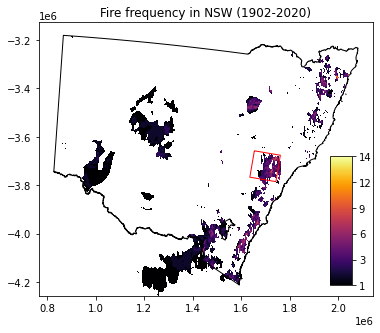

In [62]:
os.chdir('/p8/fdlausnz/yshendryk/risk_heatmaping/data/')
aoi = gpd.read_file('vector/S2_T56HKJ_bbox_Albers.shp')
nsw_bound = gpd.read_file('vector/NSW_boundary_Albers.shp')
fire_freq = rasterio.open("raster/Fire_NPWSFireHistory_1902_2020_freq_Albers.tif")
fig, ax = plt.subplots(figsize=(6, 6))
rasterio.plot.show(fire_freq, ax=ax, cmap='inferno')
plt.title('Fire frequency in NSW (1902-2020)')
col_map = plt.get_cmap('inferno')
# Custom colorbar, as rasterio is dumb
c_map_ax = fig.add_axes([0.8, 0.21, 0.05, 0.3])
cbar = mpl.colorbar.ColorbarBase(c_map_ax, cmap=col_map, orientation = 'vertical')
cbar.ax.set_yticklabels([1,3,6,9,12,14])

nsw_bound.plot(ax=ax, facecolor='none', edgecolor='k')
aoi.plot(ax=ax, facecolor='none', edgecolor='r')

In [13]:
#!gdal_rasterize -a 'Join_Count' -of GTiff -tr 1000 1000 -a_nodata 0 'Fire_NPWSFireHistory_1902_2020_freq.shp' '/p8/fdlausnz/yshendryk/data/Fire_NPWSFireHistory_1902_2020_freq.tif'

0^C


In [6]:
#nsw_bound.plot(facecolor="none", edgecolor="black")
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
#fire_freq_single.plot(column='Join_Count', ax=ax, legend=True, cax=cax)

In [ ]:
!/p8/fdlausnz/yshendryk/aria2c /p8/fdlausnz/yshendryk/risk_heatmaping/ancillary/T56HKJ_L2A.meta4 -d /p8/fdlausnz/yshendryk/data/T56HKJ

In [17]:
!cat /proc/meminfo | grep Mem

MemTotal:       131999288 kB
MemFree:        107289508 kB
MemAvailable:   112018996 kB


In [7]:
## 40 logical cores (CPU(s) = Thread(s) per core * Core(s) per socket * Socket(s))
## Each core can run 2 threads
!lscpu

Architecture:          x86_64
CPU op-mode(s):        32-bit, 64-bit
Byte Order:            Little Endian
CPU(s):                40
On-line CPU(s) list:   0-39
Thread(s) per core:    2
Core(s) per socket:    10
Socket(s):             2
NUMA node(s):          2
Vendor ID:             GenuineIntel
CPU family:            6
Model:                 62
Model name:            Intel(R) Xeon(R) CPU E5-2660 v2 @ 2.20GHz
Stepping:              4
CPU MHz:               2254.742
CPU max MHz:           3000.0000
CPU min MHz:           1200.0000
BogoMIPS:              4399.81
Virtualization:        VT-x
L1d cache:             32K
L1i cache:             32K
L2 cache:              256K
L3 cache:              25600K
NUMA node0 CPU(s):     0-9,20-29
NUMA node1 CPU(s):     10-19,30-39
Flags:                 fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush dts acpi mmx fxsr sse sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm constant_tsc arch_perfmon pebs bts rep_good nopl xtopo

In [ ]:
!htop

In [8]:
!ls

data  risk_heatmaping  Test.ipynb
